# **When Consumers Misjudge Privacy Costs**
**Master's Thesis in Economics June 2026**

# Table of contents
* [Imports and Set Magic](#toc0_)   

* [1 Calibrating Equilibria for Varying epsilon and s](#toc1_) 

* [2 Functions of Epsilon](#toc2_)    

* [3 Functions of s](#toc3_)    

* [4 Introducing Naïveté](#toc4_)   

* [5 Welfare Comparisons](#toc5_) 

* [6: Symmetric Case](#toc6_) 

## <a id='toc0_'></a>[Imports and Set Magic](#toc0_)

In [3]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar

In [7]:
# Set magics
# use autoreload to only reload the user-written functions 
%load_ext autoreload
%autoreload 1

%aimport model 
# %aimport vareps
# %aimport baseline
# ^can be taken into usee when needed; they're in a separate folder, need to be taken out first

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## <a id='toc1_'></a>[1 Calibrating Equilibria for Varying epsilon and s](#toc1_)

In [24]:
eps_grid = np.linspace(0.0, 0.5, 25)   # preference strength
s_grid   = np.linspace(0.001, 0.5, 25) # search cost (avoid 0 exactly)
prev_p1, prev_p2 = 0.5, 0.5
mu = 0.75
sigma = 1
gamma = 0

In [25]:
results_highs = model.equilibrium_path_s_eps(eps_grid, s_grid, gamma, mu, sigma, prev_p1, prev_p2)
df_highs = pd.DataFrame(results_highs)

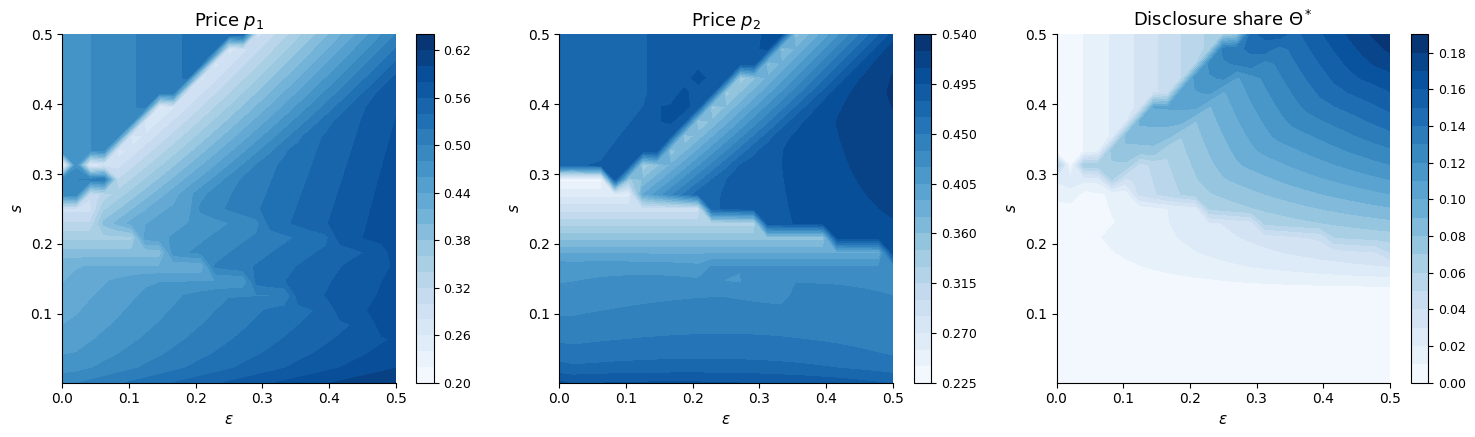

In [26]:
model.plot_colorblock(df_highs, eps_grid, s_grid)

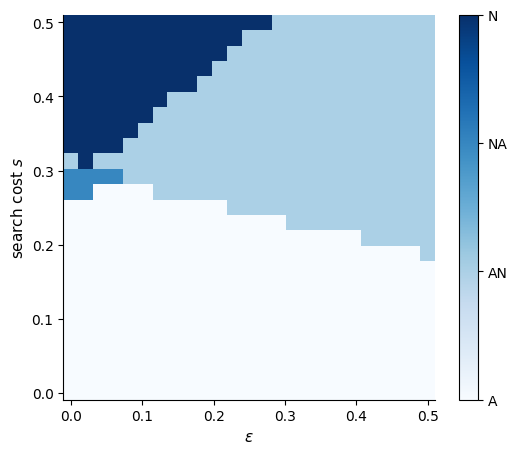

In [27]:
mixed_highs = model.find_mixed_regions(df_highs)
model.plot_regime_map(df_highs, eps_grid, s_grid)

# Welfare comparison

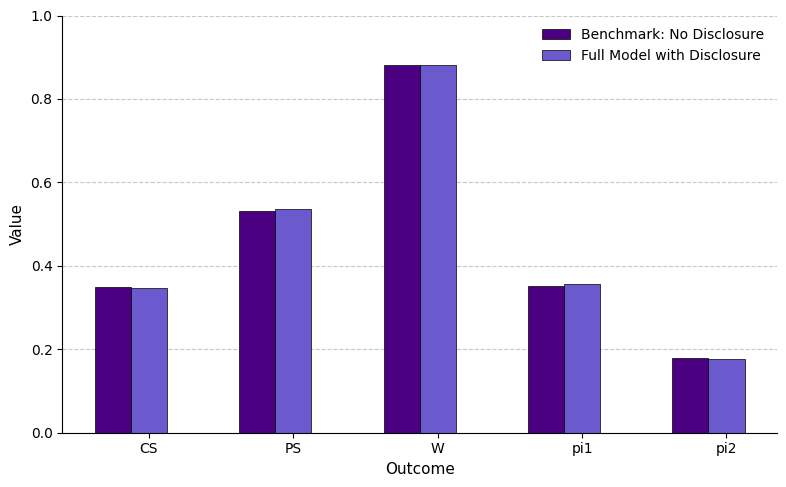

In [19]:
df_compare_AN = model.compare_outcomes_benchmark(eps=0.5, s=0.25, mu=0.75, sigma=1)
model.plot_welfare_comparison(df_compare_AN)

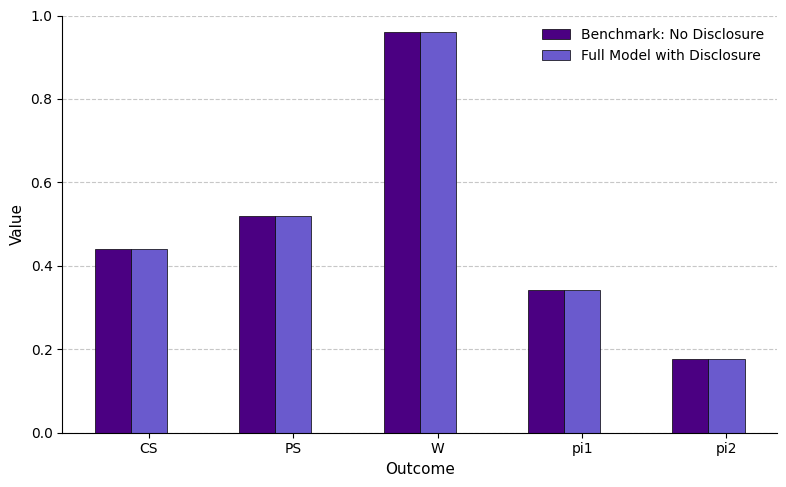

In [20]:
df_compare_A = model.compare_outcomes_benchmark(eps=0.5, s=0.15, mu=0.75, sigma=1)
model.plot_welfare_comparison(df_compare_A)

In [21]:
print(df_compare_AN.head(round(3)))

                                  p1        p2       pi1       pi2        CS  \
Benchmark: No Disclosure    0.583867  0.508031  0.352513  0.179887  0.348949   
Full Model with Disclosure  0.592647  0.511649  0.357553  0.177584   0.34617   

                                  PS         W     Theta regime  
Benchmark: No Disclosure      0.5324  0.881349         0     AN  
Full Model with Disclosure  0.535137  0.881307  0.088614     AN  


In [22]:
print(df_compare_A.head(round(3)))

                                  p1        p2       pi1       pi2        CS  \
Benchmark: No Disclosure    0.583737  0.431217  0.342556  0.176885  0.441092   
Full Model with Disclosure  0.584523  0.430315  0.343207  0.176458  0.441115   

                                  PS         W     Theta regime  
Benchmark: No Disclosure    0.519441  0.960533         0      A  
Full Model with Disclosure  0.519665  0.960781  0.017937      A  
